# CyberSentinel Analytics — Data Profiling PC1

Ce notebook analyse automatiquement les fichiers bruts du poste **PC1** avant la création de la Silver Layer.

Il produit :

- un inventaire des fichiers ;
- le nombre de lignes et de colonnes ;
- les types de données ;
- les valeurs manquantes ;
- les doublons ;
- les statistiques descriptives ;
- les valeurs uniques ;
- la détection automatique des colonnes temporelles ;
- les problèmes de qualité potentiels ;
- des rapports CSV et JSON dans `data/profiling/pc1/`.

> Le notebook ne modifie jamais les fichiers Raw.


In [17]:
# À exécuter une seule fois si nécessaire
# %pip install pandas numpy matplotlib openpyxl

from pathlib import Path
import json
import re
import hashlib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)


## 1. Configuration des chemins

In [3]:
# Le notebook peut être placé dans:
# cybersentinel-analytics/data_profiling/
#
# Il recherche automatiquement la racine du projet.

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    candidates = [current, *current.parents]

    for candidate in candidates:
        if (candidate / "data" / "raw" / "local").exists():
            return candidate

    raise FileNotFoundError(
        "Impossible de trouver la racine du projet. "
        "Vérifie que le dossier data/raw/local existe."
    )


PROJECT_ROOT = find_project_root()

PC_NAME = "pc1"
RAW_PC_DIR = PROJECT_ROOT / "data" / "raw" / "local" / PC_NAME / "logs"
PROFILE_DIR = PROJECT_ROOT / "data" / "profiling" / PC_NAME

PROFILE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_PC_DIR   :", RAW_PC_DIR)
print("PROFILE_DIR  :", PROFILE_DIR)

if not RAW_PC_DIR.exists():
    raise FileNotFoundError(f"Dossier introuvable: {RAW_PC_DIR}")


PROJECT_ROOT : C:\Users\user1\cybersentinel-analytics
RAW_PC_DIR   : C:\Users\user1\cybersentinel-analytics\data\raw\local\pc1\logs
PROFILE_DIR  : C:\Users\user1\cybersentinel-analytics\data\profiling\pc1


## 2. Fonctions utilitaires

In [5]:
SUPPORTED_EXTENSIONS = {".csv", ".json", ".jsonl"}

TIMESTAMP_KEYWORDS = {"time", "date", "timestamp", "created", "modified", "detected", "remediation", "extracted"}
IDENTIFIER_KEYWORDS = {"id", "guid", "sid", "hash", "serial", "record"}
HOST_KEYWORDS = {"hostname", "host", "computer", "machine", "device_name"}
USER_KEYWORDS = {"username", "user", "account", "subjectusername", "targetusername"}
IP_KEYWORDS = {"ip", "source_ip", "destination_ip", "src_ip", "dst_ip", "remote_ip", "local_ip"}


def column_tokens(column: str) -> set[str]:
    return {token for token in re.split(r"[^a-z0-9]+", column.lower()) if token}


def matches_role(column: str, keywords: set[str]) -> bool:
    normalized = safe_column_name(column)
    tokens = column_tokens(normalized)
    return normalized in keywords or bool(tokens & keywords)


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def safe_column_name(column: str) -> str:
    value = re.sub(r"[^A-Za-z0-9_]+", "_", str(column).strip())
    return value.strip("_").lower() or "unnamed_column"


def make_unique_columns(columns) -> list[str]:
    result, counts = [], {}
    for column in columns:
        base = safe_column_name(column)
        counts[base] = counts.get(base, 0) + 1
        result.append(base if counts[base] == 1 else f"{base}_{counts[base]}")
    return result


def detect_encoding(path: Path) -> str:
    for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin-1"):
        try:
            path.read_text(encoding=encoding)[:65536]
            return encoding
        except UnicodeDecodeError:
            continue
    return "latin-1"


def read_csv_robust(path: Path) -> pd.DataFrame:
    encoding = detect_encoding(path)
    attempts = (
        {"sep": None, "engine": "python"},
        {"sep": ",", "engine": "c", "low_memory": False},
        {"sep": ";", "engine": "c", "low_memory": False},
        {"sep": "\t", "engine": "c", "low_memory": False},
    )
    errors = []
    for params in attempts:
        try:
            df = pd.read_csv(path, encoding=encoding, on_bad_lines="skip", **params)
            if len(df.columns) == 1 and params["sep"] is not None:
                continue
            df.columns = make_unique_columns(df.columns)
            return df
        except (pd.errors.ParserError, UnicodeError, ValueError) as error:
            errors.append(f"{params}: {error}")
    raise RuntimeError(f"Impossible de lire {path.name}: {' | '.join(errors)}")


def read_json_robust(path: Path) -> pd.DataFrame:
    encoding = detect_encoding(path)
    if path.suffix.lower() == ".jsonl":
        return pd.read_json(path, lines=True, encoding=encoding)
    with path.open("r", encoding=encoding, errors="strict") as file:
        data = json.load(file)
    if isinstance(data, list):
        return pd.json_normalize(data)
    if isinstance(data, dict):
        return pd.json_normalize([data])
    raise ValueError("Structure JSON non prise en charge")


def normalize_complex_values(df: pd.DataFrame) -> pd.DataFrame:
    # Make nested JSON values profileable without changing the Raw source.
    result = df.copy()
    for column in result.columns:
        if result[column].dtype != "object":
            continue
        result[column] = result[column].map(
            lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True)
            if isinstance(value, (dict, list, tuple, set))
            else value
        )
    return result


def load_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return normalize_complex_values(read_csv_robust(path))
    if path.suffix.lower() in {".json", ".jsonl"}:
        df = read_json_robust(path)
        df.columns = make_unique_columns(df.columns)
        return normalize_complex_values(df)
    raise ValueError(f"Extension non supportée: {path.suffix}")


def sample_values(series: pd.Series, limit: int = 5) -> list[str]:
    values = series.dropna().astype(str).str.strip()
    return values[~values.isin({"", "nan", "None"})].drop_duplicates().head(limit).tolist()


def detect_timestamp_columns(df: pd.DataFrame) -> list[str]:
    result = []
    for column in df.columns:
        if matches_role(column, TIMESTAMP_KEYWORDS):
            result.append(column)
            continue
        if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(df[column]):
            sample = df[column].dropna().astype(str).head(200)
            if len(sample) >= 3 and pd.to_datetime(sample, errors="coerce", utc=True).notna().mean() >= 0.8:
                result.append(column)
    return result


def detect_identifier_columns(df: pd.DataFrame) -> list[str]:
    return [column for column in df.columns if matches_role(column, IDENTIFIER_KEYWORDS)]


def classify_column(series: pd.Series, column_name: str) -> str:
    for role, keywords in (("datetime_candidate", TIMESTAMP_KEYWORDS), ("ip_address", IP_KEYWORDS), ("host", HOST_KEYWORDS), ("user", USER_KEYWORDS), ("identifier", IDENTIFIER_KEYWORDS)):
        if matches_role(column_name, keywords):
            return role
    if pd.api.types.is_bool_dtype(series):
        return "boolean"
    if pd.api.types.is_numeric_dtype(series):
        return "numeric"
    return "categorical" if series.nunique(dropna=True) <= 50 else "text"


def invalid_ip_rate(series: pd.Series) -> float | None:
    import ipaddress
    values = series.dropna().astype(str).str.strip()
    values = values[~values.isin({"", "-"})]
    if values.empty:
        return None
    def valid(value: str) -> bool:
        try:
            ipaddress.ip_address(value)
            return True
        except ValueError:
            return False
    return round((~values.map(valid)).mean() * 100, 2)


## 3. Inventaire des fichiers PC1

In [6]:
all_files = sorted(
    path
    for path in RAW_PC_DIR.rglob("*")
    if path.is_file()
)

data_files = [
    path
    for path in all_files
    if path.suffix.lower() in SUPPORTED_EXTENSIONS
]

inventory_rows = []

for path in all_files:
    inventory_rows.append({
        "file_name": path.name,
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "extension": path.suffix.lower(),
        "size_bytes": path.stat().st_size,
        "size_mb": round(path.stat().st_size / (1024 ** 2), 3),
        "modified_at": datetime.fromtimestamp(path.stat().st_mtime),
        "is_supported": path.suffix.lower() in SUPPORTED_EXTENSIONS,
        "sha256": sha256_file(path),
    })

inventory_df = pd.DataFrame(inventory_rows)

display(inventory_df)

inventory_df.to_csv(
    PROFILE_DIR / "file_inventory.csv",
    index=False,
    encoding="utf-8-sig",
)

print(f"{len(all_files)} fichiers trouvés")
print(f"{len(data_files)} fichiers analysables")


,file_name,relative_path,extension,size_bytes,size_mb,modified_at,is_supported,sha256
0,antivirus_logs.csv,data\raw\local\pc1\logs\antivirus_logs.csv,.csv,122642,0.117,2026-07-23 12:10:26.750900,True,90e7c0cca4204a155ab231f48bfd9e71689cad5b5e407d0ee38f722ac99f0483
1,authentication_logs.csv,data\raw\local\pc1\logs\authentication_logs.csv,.csv,21446994,20.453,2026-07-23 12:10:30.485457,True,53acb425a7108fa7bc07e45f049791b2a37c546803af9e3afa570a10762fa565
2,collector_diagnostics.json,data\raw\local\pc1\logs\collector_diagnostics.json,.json,7074,0.007,2026-07-23 12:10:30.759144,True,40e86d58f6b6e7ace73b5aa16f4bd476c8835b521955abbb6994846eac2d86f7
3,collector_errors.log,data\raw\local\pc1\logs\collector_errors.log,.log,384,0.000,2026-07-23 12:10:31.010166,False,5a8a5bc4c77ed5837fc9fdaf69df540ec5c0f5cea6889b114c5fd33c618792c5
4,collector_status.json,data\raw\local\pc1\logs\collector_status.json,.json,668,0.001,2026-07-23 12:10:31.353544,True,fe70fbfbbce82a4fdada626f86e48fe15a510eff5f0a85aa5426cf37aadf4b2f
5,consent_record.json,data\raw\local\pc1\logs\consent_record.json,.json,521,0.000,2026-07-23 12:10:31.594968,True,6a051d647edf7d1f3488065002646ad32d66c9873a92f2bcae7990d81a05094d
6,data_quality_report.csv,data\raw\local\pc1\logs\data_quality_report.csv,.csv,2234,0.002,2026-07-23 12:10:31.925492,True,ff2d45180975a1d4d76ce79e14ddb50762ed6786f7370f6769d3a043eabd136d
7,defender_threats.csv,data\raw\local\pc1\logs\defender_threats.csv,.csv,2015,0.002,2026-07-23 12:10:32.224171,True,910351a875cad90a732489c0acff5ca8e2666de29e89a667619c62c6db156cb3
8,extraction_report.csv,data\raw\local\pc1\logs\extraction_report.csv,.csv,2187,0.002,2026-07-23 12:10:32.492594,True,c5f7f93c58d2aee2b4a85a432d402e5a2483e5382eaecbea286225e0afe7a550
9,file_metadata.json,data\raw\local\pc1\logs\file_metadata.json,.json,11445,0.011,2026-07-23 12:10:32.849185,True,ba75145f0d35a80e206a4d5b9d7ea6cbff66fac1bd7796fca8e13de7ac9b25bb


20 fichiers trouvés
18 fichiers analysables


## 4. Profiling automatique de tous les datasets

In [7]:
dataset_summary_rows = []
column_profile_rows = []
quality_issue_rows = []
loaded_datasets = {}

for file_path in data_files:
    print(f"Analyse: {file_path.name}")

    try:
        df = load_dataset(file_path)
        loaded_datasets[file_path.name] = df

        row_count = len(df)
        column_count = len(df.columns)
        duplicate_count = int(df.duplicated().sum())
        duplicate_rate = round(
            (duplicate_count / row_count * 100) if row_count else 0,
            2,
        )

        total_cells = row_count * column_count
        missing_cells = int(df.isna().sum().sum())
        missing_rate = round(
            (missing_cells / total_cells * 100) if total_cells else 0,
            2,
        )

        timestamp_columns = detect_timestamp_columns(df)
        identifier_columns = detect_identifier_columns(df)

        dataset_summary_rows.append({
            "file_name": file_path.name,
            "relative_path": str(file_path.relative_to(PROJECT_ROOT)),
            "rows": row_count,
            "columns": column_count,
            "duplicate_rows": duplicate_count,
            "duplicate_rate_pct": duplicate_rate,
            "missing_cells": missing_cells,
            "missing_rate_pct": missing_rate,
            "memory_mb": round(
                df.memory_usage(deep=True).sum() / (1024 ** 2),
                3,
            ),
            "timestamp_columns": ", ".join(timestamp_columns),
            "identifier_columns": ", ".join(identifier_columns),
            "status": "Success",
            "error": None,
        })

        if row_count == 0:
            quality_issue_rows.append({
                "file_name": file_path.name,
                "column": None,
                "issue_type": "empty_dataset",
                "severity": "high",
                "details": "Le dataset ne contient aucune ligne.",
            })

        if duplicate_rate > 0:
            quality_issue_rows.append({
                "file_name": file_path.name,
                "column": None,
                "issue_type": "duplicate_rows",
                "severity": "medium" if duplicate_rate < 5 else "high",
                "details": f"{duplicate_count} doublons ({duplicate_rate}%).",
            })

        for column in df.columns:
            series = df[column]
            missing_count = int(series.isna().sum())
            missing_pct = round(
                (missing_count / row_count * 100) if row_count else 0,
                2,
            )
            unique_count = int(series.nunique(dropna=True))
            unique_pct = round(
                (unique_count / row_count * 100) if row_count else 0,
                2,
            )
            inferred_role = classify_column(series, column)

            profile_row = {
                "file_name": file_path.name,
                "column_name": column,
                "pandas_dtype": str(series.dtype),
                "inferred_role": inferred_role,
                "non_null_count": int(series.notna().sum()),
                "missing_count": missing_count,
                "missing_pct": missing_pct,
                "unique_count": unique_count,
                "unique_pct": unique_pct,
                "sample_values": json.dumps(
                    sample_values(series),
                    ensure_ascii=False,
                ),
                "min_value": None,
                "max_value": None,
                "mean_value": None,
                "median_value": None,
                "invalid_ip_pct": None,
                "datetime_parse_success_pct": None,
                "datetime_min": None,
                "datetime_max": None,
            }

            if pd.api.types.is_numeric_dtype(series):
                numeric = pd.to_numeric(series, errors="coerce")
                profile_row.update({
                    "min_value": numeric.min(),
                    "max_value": numeric.max(),
                    "mean_value": numeric.mean(),
                    "median_value": numeric.median(),
                })

            if inferred_role == "ip_address":
                profile_row["invalid_ip_pct"] = invalid_ip_rate(series)

            if column in timestamp_columns:
                parsed = pd.to_datetime(series, errors="coerce", utc=True)
                profile_row["datetime_parse_success_pct"] = round(
                    parsed.notna().mean() * 100,
                    2,
                )
                profile_row["datetime_min"] = (
                    parsed.min().isoformat()
                    if parsed.notna().any()
                    else None
                )
                profile_row["datetime_max"] = (
                    parsed.max().isoformat()
                    if parsed.notna().any()
                    else None
                )

                if profile_row["datetime_parse_success_pct"] < 90:
                    quality_issue_rows.append({
                        "file_name": file_path.name,
                        "column": column,
                        "issue_type": "datetime_parse_failure",
                        "severity": "high",
                        "details": (
                            f"Seulement "
                            f"{profile_row['datetime_parse_success_pct']}% "
                            f"des valeurs peuvent être converties en datetime."
                        ),
                    })

            if missing_pct >= 50:
                quality_issue_rows.append({
                    "file_name": file_path.name,
                    "column": column,
                    "issue_type": "high_missing_rate",
                    "severity": "high",
                    "details": f"{missing_pct}% de valeurs manquantes.",
                })

            elif missing_pct >= 20:
                quality_issue_rows.append({
                    "file_name": file_path.name,
                    "column": column,
                    "issue_type": "medium_missing_rate",
                    "severity": "medium",
                    "details": f"{missing_pct}% de valeurs manquantes.",
                })

            if unique_count == 1 and row_count > 1:
                quality_issue_rows.append({
                    "file_name": file_path.name,
                    "column": column,
                    "issue_type": "constant_column",
                    "severity": "low",
                    "details": "La colonne contient une seule valeur distincte.",
                })

            if inferred_role == "ip_address":
                invalid_rate = profile_row["invalid_ip_pct"]

                if invalid_rate is not None and invalid_rate > 5:
                    quality_issue_rows.append({
                        "file_name": file_path.name,
                        "column": column,
                        "issue_type": "invalid_ip_values",
                        "severity": "medium",
                        "details": f"{invalid_rate}% d'adresses IP atypiques/invalides.",
                    })

            column_profile_rows.append(profile_row)

    except Exception as error:
        dataset_summary_rows.append({
            "file_name": file_path.name,
            "relative_path": str(file_path.relative_to(PROJECT_ROOT)),
            "rows": None,
            "columns": None,
            "duplicate_rows": None,
            "duplicate_rate_pct": None,
            "missing_cells": None,
            "missing_rate_pct": None,
            "memory_mb": None,
            "timestamp_columns": None,
            "identifier_columns": None,
            "status": "Failed",
            "error": str(error),
        })

        quality_issue_rows.append({
            "file_name": file_path.name,
            "column": None,
            "issue_type": "read_error",
            "severity": "critical",
            "details": str(error),
        })

dataset_summary_df = pd.DataFrame(dataset_summary_rows)
column_profile_df = pd.DataFrame(column_profile_rows)
quality_issues_df = pd.DataFrame(quality_issue_rows)

display(Markdown("### Résumé par fichier"))
display(dataset_summary_df)

display(Markdown("### Problèmes de qualité détectés"))
display(quality_issues_df.head(200))


Analyse: antivirus_logs.csv
Analyse: authentication_logs.csv
Analyse: collector_diagnostics.json
Analyse: collector_status.json
Analyse: consent_record.json
Analyse: data_quality_report.csv
Analyse: defender_threats.csv
Analyse: extraction_report.csv
Analyse: file_metadata.json
Analyse: firewall_logs.csv
Analyse: machine_inventory.csv
Analyse: manifest.json
Analyse: network_inventory.csv
Analyse: schema_manifest.json
Analyse: usb_devices.csv
Analyse: usb_event_logs.csv
Analyse: windows_application_logs.csv
Analyse: windows_system_logs.csv


### Résumé par fichier

,file_name,relative_path,rows,columns,duplicate_rows,duplicate_rate_pct,missing_cells,missing_rate_pct,memory_mb,timestamp_columns,identifier_columns,status,error
0,antivirus_logs.csv,data\raw\local\pc1\logs\antivirus_logs.csv,48,117,0,0.00,2491,44.36,0.242,"timestamp_utc, collector_version, extracted_at_utc, enriched_at_utc","collection_id, machine_id, event_id, event_record_id, raw_event_hash, threat_id, process_id, thread_id, activity_id,...",Success,None
1,authentication_logs.csv,data\raw\local\pc1\logs\authentication_logs.csv,4629,133,0,0.00,238821,38.79,56.214,"timestamp_utc, collector_version, extracted_at_utc, mitre_id, enriched_at_utc","collection_id, machine_id, event_id, event_record_id, raw_event_hash, user_sid, source_ip_hash, destination_ip_hash,...",Success,None
2,collector_diagnostics.json,data\raw\local\pc1\logs\collector_diagnostics.json,1,128,0,0.00,10,7.81,0.005,"defender_status_real_time_protection_enabled, collector_health_execution_time","collection_id, machine_id, collector_health_machine_id",Success,None
3,collector_status.json,data\raw\local\pc1\logs\collector_status.json,1,21,0,0.00,5,23.81,0.001,execution_time,machine_id,Success,None
4,consent_record.json,data\raw\local\pc1\logs\consent_record.json,1,14,0,0.00,0,0.00,0.001,,"consent_id, collection_id, machine_id",Success,None
5,data_quality_report.csv,data\raw\local\pc1\logs\data_quality_report.csv,10,11,0,0.00,0,0.00,0.005,,,Success,None
6,defender_threats.csv,data\raw\local\pc1\logs\defender_threats.csv,0,106,0,0.00,0,0.00,0.000,"timestamp_utc, extracted_at_utc, initial_detection_time, last_status_change_time, remediation_time","collection_id, machine_id, event_id, event_record_id, raw_event_hash, threat_id, threat_status_id, execution_status_...",Success,None
7,extraction_report.csv,data\raw\local\pc1\logs\extraction_report.csv,11,19,0,0.00,19,9.09,0.005,"rows_extracted, oldest_event_timestamp, newest_event_timestamp",,Success,None
8,file_metadata.json,data\raw\local\pc1\logs\file_metadata.json,12,24,0,0.00,8,2.78,0.012,"collector_version, collection_start_utc, collection_end_utc, rows_extracted, oldest_event_timestamp, newest_event_ti...","machine_id, collection_id",Success,None
9,firewall_logs.csv,data\raw\local\pc1\logs\firewall_logs.csv,100000,127,8282,8.28,3056051,24.06,508.410,"timestamp_utc, collector_version, extracted_at_utc, firewall_last_modified, enriched_at_utc","collection_id, machine_id, event_id, event_record_id, raw_event_hash, source_ip_hash, destination_ip_hash, mitre_id,...",Success,None


### Problèmes de qualité détectés

,file_name,column,issue_type,severity,details
0,antivirus_logs.csv,collection_id,constant_column,low,La colonne contient une seule valeur distincte.
1,antivirus_logs.csv,machine_id,constant_column,low,La colonne contient une seule valeur distincte.
2,antivirus_logs.csv,hostname,constant_column,low,La colonne contient une seule valeur distincte.
3,antivirus_logs.csv,hostname_raw,constant_column,low,La colonne contient une seule valeur distincte.
4,antivirus_logs.csv,hostname_public,constant_column,low,La colonne contient une seule valeur distincte.
5,antivirus_logs.csv,event_id,constant_column,low,La colonne contient une seule valeur distincte.
6,antivirus_logs.csv,category,constant_column,low,La colonne contient une seule valeur distincte.
7,antivirus_logs.csv,channel,constant_column,low,La colonne contient une seule valeur distincte.
8,antivirus_logs.csv,provider,constant_column,low,La colonne contient une seule valeur distincte.
9,antivirus_logs.csv,level,constant_column,low,La colonne contient une seule valeur distincte.


In [8]:
for file_name, df in loaded_datasets.items():
    display(Markdown(f"## `{file_name}`"))

    print(f"Shape: {df.shape}")
    display(df.head(5))

    display(Markdown("### Types de données"))
    display(
        pd.DataFrame({
            "column": df.columns,
            "dtype": [str(df[col].dtype) for col in df.columns],
            "non_null": [int(df[col].notna().sum()) for col in df.columns],
            "missing": [int(df[col].isna().sum()) for col in df.columns],
            "unique": [int(df[col].nunique(dropna=True)) for col in df.columns],
        })
    )

    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

    if numeric_columns:
        display(Markdown("### Statistiques numériques"))
        display(df[numeric_columns].describe().T)

    categorical_columns = [
        col
        for col in df.columns
        if df[col].dtype == "object"
    ][:20]

    if categorical_columns:
        display(Markdown("### Valeurs fréquentes"))
        for column in categorical_columns:
            print(f"\n{column}")
            display(
                df[column]
                .fillna("<NULL>")
                .astype(str)
                .value_counts(dropna=False)
                .head(10)
                .rename("count")
                .to_frame()
            )


## `antivirus_logs.csv`

Shape: (48, 117)


,collection_id,machine_id,hostname,hostname_raw,hostname_public,timestamp_utc,event_id,event_record_id,category,channel,provider,level,level_raw,severity_normalized,message,message_status,data_origin,collector_version,extracted_at_utc,source_file,event_uid,raw_event_hash,threat_id,threat_name,threat_category,threat_severity,resource_path,process_name,username,action_name,action_status,detection_source,detection_origin,detection_type,error_code,error_description,engine_version,security_intelligence_version,process_id,thread_id,activity_id,raw_xml,source_country,destination_country,source_city,destination_city,source_asn,destination_asn,source_organization,destination_organization,...,source_geoip_status,destination_geoip_status,source_dns_status,destination_dns_status,source_threat_intel_status,destination_threat_intel_status,process_sha256,process_md5,process_signed,process_signature_status,process_publisher,process_company,process_description,event_family,event_action,event_category_normalized,security_domain,mitre_tactic,mitre_technique,mitre_id,mitre_confidence,classification_rule_id,classification_version,requires_correlation,risk_score,risk_level,risk_reasons,risk_components,risk_rule_version,risk_confidence,enrichment_status,enrichment_provider,enrichment_version,enriched_at_utc,geoip_status,dns_status,threat_intel_status,process_enrichment_status,enrichment_error,quality_score,missing_percentage,duplicate_percentage,parsing_errors,validation_status,quality_rule_version,execution_process_id,keywords,opcode,task,user_sid
0,COL_20260723T101849Z_A4EF70,MACHINE_D457FD2A8221,charaf-soubi,charaf-soubi,HOST_DDDEC58D,2026-06-04T15:28:01.509Z,5007,2829,DEFENDER_EVENTS,Microsoft-Windows-Windows Defender/Operational,Microsoft-Windows-Windows Defender,Information,Information,Low,Microsoft Defender Antivirus Configuration has changed. If this is an unexpected event you should review the setting...,AVAILABLE,REAL_CONSENTED,2.1.0,2026-07-23T10:18:49.752Z,antivirus_logs.csv,036ef67acb8e2abda33fcdab7589ba4283f6d069f433b83990dc08a5fd550b3b,0466986ce6d77b85327e9cde5d2b31edda58a918e2321bdc13bddf34f9255961,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0.0.0,NaN,6088,4916,NaN,<Event xmlns='http://schemas.microsoft.com/win/2004/08/events/event'><System><Provider Name='Microsoft-Windows-Windo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Defender,Threat Detection,Endpoint Protection,Endpoint Security,TA0002,NaN,NaN,HIGH,CS-DEFENDER_EVENTS-5007,1.0.0,False,75,High,Low severity | Defender threat event,"{""defender"":70,""severity"":5}",1.0.0,HIGH,NOT_APPLICABLE,OFFLINE_DEFAULT | OFFLINE_DEFAULT | WINDOWS_AUTHENTICODE,1.0.0,2026-07-23T10:18:49.752Z,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,100,0,0,0,PASS,1.0.0,6088,NaN,Informations,NaN,SID_51261F635DA4
1,COL_20260723T101849Z_A4EF70,MACHINE_D457FD2A8221,charaf-soubi,charaf-soubi,HOST_DDDEC58D,2026-06-04T15:28:00.488Z,5007,2828,DEFENDER_EVENTS,Microsoft-Windows-Windows Defender/Operational,Microsoft-Windows-Windows Defender,Information,Information,Low,Microsoft Defender Antivirus Configuration has changed. If this is an unexpected event you should review the setting...,AVAILABLE,REAL_CONSENTED,2.1.0,2026-07-23T10:18:49.752Z,antivirus_logs.csv,3520554ffeea74f8980fc998d4b9474af17d9e7ac49c32a5d05d31e506a9e176,478a35f4ee605677ef3fc968f6b68bfa7e58709848abfc8828ef1cc80701dcf6,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,Failed,NaN,NaN,NaN,NaN,NaN,0.0.0.0,NaN,6088,6116,NaN,<Event xmlns='http://schemas.microsoft.com/win/2004/08/events/event'><System><Provider Name='Microsoft-Windows-Windo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Defender,Threat Detection,Endpoint Protection,Endpoint Security,TA0002,NaN,NaN,HIGH,CS-DEFENDER_EVENTS-5007,1.0.0,False,90,Critic

### Types de données

,column,dtype,non_null,missing,unique
0,collection_id,str,48,0,1
1,machine_id,str,48,0,1
2,hostname,str,48,0,1
3,hostname_raw,str,48,0,1
4,hostname_public,str,48,0,1
5,timestamp_utc,str,48,0,14
6,event_id,int64,48,0,1
7,event_record_id,int64,48,0,48
8,category,str,48,0,1
9,channel,str,48,0,1


...

,collection_id,machine_id,hostname,hostname_raw,hostname_public,timestamp_utc,event_id,event_record_id,category,channel,provider,level,level_raw,severity_normalized,message,message_status,data_origin,collector_version,extracted_at_utc,source_file,event_uid,raw_event_hash,process_id,thread_id,activity_id,task,opcode,keywords,user_sid,execution_process_id,system_classification,raw_xml,source_country,destination_country,source_city,destination_city,source_asn,destination_asn,source_organization,destination_organization,source_latitude,destination_latitude,source_longitude,destination_longitude,source_hostname,destination_hostname,source_ip_reputation,destination_ip_reputation,source_ip_risk,destination_ip_risk,...,destination_threat_feed,source_threat_category,destination_threat_category,threat_feed,threat_category,source_geoip_status,destination_geoip_status,source_dns_status,destination_dns_status,source_threat_intel_status,destination_threat_intel_status,process_sha256,process_md5,process_signed,process_signature_status,process_publisher,process_company,process_description,event_family,event_action,event_category_normalized,security_domain,mitre_tactic,mitre_technique,mitre_id,mitre_confidence,classification_rule_id,classification_version,requires_correlation,risk_score,risk_level,risk_reasons,risk_components,risk_rule_version,risk_confidence,enrichment_status,enrichment_provider,enrichment_version,enriched_at_utc,geoip_status,dns_status,threat_intel_status,process_enrichment_status,enrichment_error,quality_score,missing_percentage,duplicate_percentage,parsing_errors,validation_status,quality_rule_version
0,COL_20260723T101849Z_A4EF70,MACHINE_D457FD2A8221,charaf-soubi,charaf-soubi,HOST_DDDEC58D,2026-07-23T10:16:55.247Z,7040,2637439,WINDOWS_SYSTEM,System,Service Control Manager,Information,Information,Low,NaN,RESOURCE_NOT_FOUND,REAL_CONSENTED,2.1.0,2026-07-23T10:18:49.752Z,windows_system_logs.csv,f771e231ecf07f1eceacca5c96df4ac15bcf8f4915a697f4789af1246c2ae29b,768ce4445e3bb6a795bb76d2f14f49b942b3f16ff7edd5e3b748fd0e4b56a7e7,884,28076,NaN,0,0,0x8080000000000000,SID_51261F635DA4,884,Service,"<Event xmlns=""http://schemas.microsoft.com/win/2004/08/events/event""><System><Provider Name=""Service Control Manager...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows System,Service,Operating System,Endpoint Security,NaN,NaN,NaN,HIGH,CS-WINDOWS_SYSTEM-7040,1.0.0,False,5,Informational,Low severity,"{""severity"":5}",1.0.0,MEDIUM,NOT_APPLICABLE,OFFLINE_DEFAULT | OFFLINE_DEFAULT | WINDOWS_AUTHENTICODE,1.0.0,2026-07-23T10:18:49.752Z,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,100,0,0,0,PASS,1.0.0
1,COL_20260723T101849Z_A4EF70,MACHINE_D457FD2A8221,charaf-soubi,charaf-soubi,HOST_DDDEC58D,2026-07-23T10:16:29.607Z,7040,2637438,WINDOWS_SYSTEM,System,Service Control Manager,Information,Information,Low,NaN,RESOURCE_NOT_FOUND,REAL_CONSENTED,2.1.0,2026-07-23T10:18:49.752Z,windows_system_logs.csv,b10e1d2dc36546fcf5d159e34141cf4b64c3a1941aa8d91d611fd7fb0015dfe5,4200164fb8166477ff21f14b6a29c3674cd4a393a40f4977d5d74f87a1e7f69b,884,9736,NaN,0,0,0x8080000000000000,SID_51261F635DA4,884,Service,"<Event xmlns=""http://schemas.microsoft.com/win/2004/08/events/event""><System><Provider Name=""Service Control Manager...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows System,Service,Operating System,Endpoint Security,NaN,NaN,NaN,HIGH,CS-WINDOWS_SYSTEM-7040,1.0.0,False,5,Informational,Low severity,"{""severity"":5}",1.0.0,MEDIUM,NOT_APPLICABLE,OFFLINE_DEFAULT | OFFLINE_DEFAULT | WINDOWS_AUTHENTICODE,1.0.0,2026-07-23T10:18:49.752Z,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NOT_APPLICABLE,NaN,100,0,0,0

### Types de données

,column,dtype,non_null,missing,unique
0,collection_id,str,50000,0,1
1,machine_id,str,50000,0,1
2,hostname,str,50000,0,1
3,hostname_raw,str,50000,0,1
4,hostname_public,str,50000,0,1
5,timestamp_utc,str,50000,0,34038
6,event_id,int64,50000,0,97
7,event_record_id,int64,50000,0,50000
8,category,str,50000,0,1
9,channel,str,50000,0,1


### Statistiques numériques

,count,mean,std,min,25%,50%,75%,max
event_id,50000.0,1.445759e+04,3216.347981,1.0,15300.00,15300.0,15301.00,51046.0
event_record_id,50000.0,2.612440e+06,14433.901067,2587440.0,2599939.75,2612439.5,2624939.25,2637439.0
message,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
process_id,50000.0,1.244434e+02,1000.787591,0.0,4.00,4.0,4.00,27412.0
thread_id,50000.0,1.337958e+04,7289.322587,0.0,8380.00,13260.0,18780.00,28648.0
task,50000.0,8.971780e+00,92.045872,0.0,0.00,0.0,0.00,1102.0
opcode,50000.0,2.090000e-02,0.913389,0.0,0.00,0.0,0.00,129.0
execution_process_id,50000.0,1.244434e+02,1000.787591,0.0,4.00,4.0,4.00,27412.0
source_country,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_country,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Analyse spécifique de chaque fichier

## 6. Analyse des colonnes communes entre les fichiers

In [11]:
schema_rows = []

for file_name, df in loaded_datasets.items():
    for column in df.columns:
        schema_rows.append({
            "file_name": file_name,
            "column_name": column,
        })

schema_df = pd.DataFrame(schema_rows)

if not schema_df.empty:
    common_columns_df = (
        schema_df.groupby("column_name")
        .agg(
            files_count=("file_name", "nunique"),
            files=("file_name", lambda values: ", ".join(sorted(set(values)))),
        )
        .sort_values(
            ["files_count", "column_name"],
            ascending=[False, True],
        )
        .reset_index()
    )

    display(common_columns_df.head(100))
else:
    common_columns_df = pd.DataFrame()

common_columns_df.to_csv(
    PROFILE_DIR / "common_columns.csv",
    index=False,
    encoding="utf-8-sig",
)


,column_name,files_count,files
0,machine_id,15,"antivirus_logs.csv, authentication_logs.csv, collector_diagnostics.json, collector_status.json, consent_record.json,..."
1,collector_version,14,"antivirus_logs.csv, authentication_logs.csv, collector_diagnostics.json, collector_status.json, defender_threats.csv..."
2,duplicate_percentage,13,"antivirus_logs.csv, authentication_logs.csv, data_quality_report.csv, defender_threats.csv, extraction_report.csv, f..."
3,hostname,13,"antivirus_logs.csv, authentication_logs.csv, collector_diagnostics.json, collector_status.json, defender_threats.csv..."
4,missing_percentage,13,"antivirus_logs.csv, authentication_logs.csv, data_quality_report.csv, defender_threats.csv, extraction_report.csv, f..."
5,parsing_errors,13,"antivirus_logs.csv, authentication_logs.csv, data_quality_report.csv, defender_threats.csv, extraction_report.csv, f..."
6,quality_rule_version,13,"antivirus_logs.csv, authentication_logs.csv, data_quality_report.csv, defender_threats.csv, extraction_report.csv, f..."
7,quality_score,13,"antivirus_logs.csv, authentication_logs.csv, data_quality_report.csv, defender_threats.csv, extraction_report.csv, f..."
8,validation_status,13,"antivirus_logs.csv, authentication_logs.csv, data_quality_report.csv, defender_threats.csv, extraction_report.csv, f..."
9,collection_id,12,"antivirus_logs.csv, authentication_logs.csv, collector_diagnostics.json, consent_record.json, defender_threats.csv, ..."


## 7. Analyse Host / User / IP

In [12]:
entity_rows = []

for file_name, df in loaded_datasets.items():
    for column in df.columns:
        role = classify_column(df[column], column)

        if role not in {"host", "user", "ip_address"}:
            continue

        value_counts = (
            df[column]
            .dropna()
            .astype(str)
            .str.strip()
            .replace("", np.nan)
            .dropna()
            .value_counts()
            .head(100)
        )

        for value, count in value_counts.items():
            entity_rows.append({
                "file_name": file_name,
                "entity_type": role,
                "column_name": column,
                "value": value,
                "count": int(count),
            })

entities_df = pd.DataFrame(entity_rows)

if not entities_df.empty:
    display(
        entities_df.sort_values(
            ["entity_type", "count"],
            ascending=[True, False],
        ).head(200)
    )
else:
    print("Aucune colonne Host/User/IP détectée.")

entities_df.to_csv(
    PROFILE_DIR / "entities_frequency.csv",
    index=False,
    encoding="utf-8-sig",
)


,file_name,entity_type,column_name,value,count
92,firewall_logs.csv,host,machine_id,MACHINE_D457FD2A8221,100000
93,firewall_logs.csv,host,hostname,charaf-soubi,100000
94,firewall_logs.csv,host,hostname_raw,charaf-soubi,100000
95,firewall_logs.csv,host,hostname_public,HOST_DDDEC58D,100000
682,windows_system_logs.csv,host,machine_id,MACHINE_D457FD2A8221,50000
683,windows_system_logs.csv,host,hostname,charaf-soubi,50000
684,windows_system_logs.csv,host,hostname_raw,charaf-soubi,50000
685,windows_system_logs.csv,host,hostname_public,HOST_DDDEC58D,50000
673,windows_application_logs.csv,host,machine_id,MACHINE_D457FD2A8221,43399
678,windows_application_logs.csv,host,hostname_public,HOST_DDDEC58D,43399


## 8. Visualisations principales

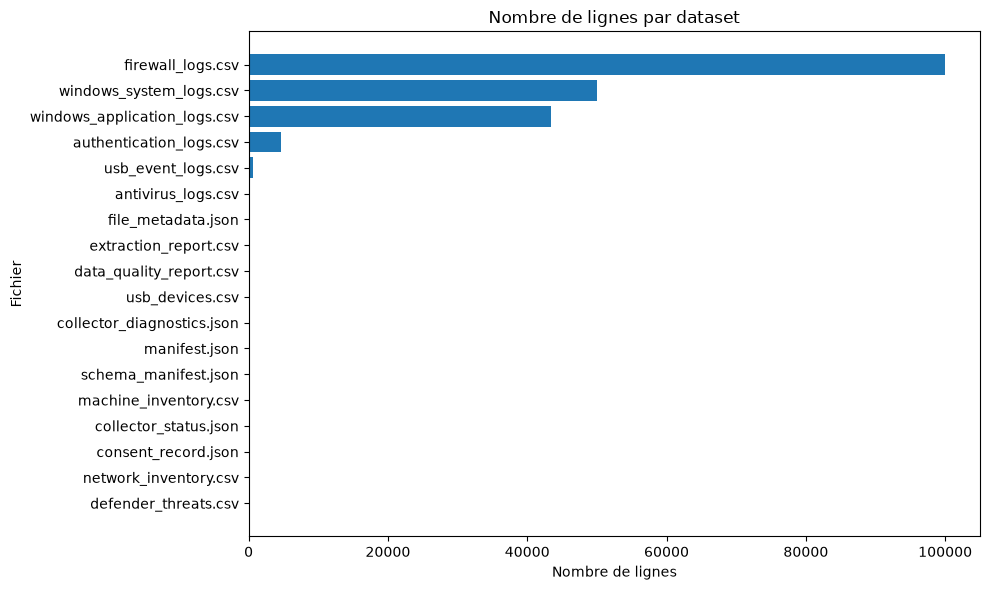

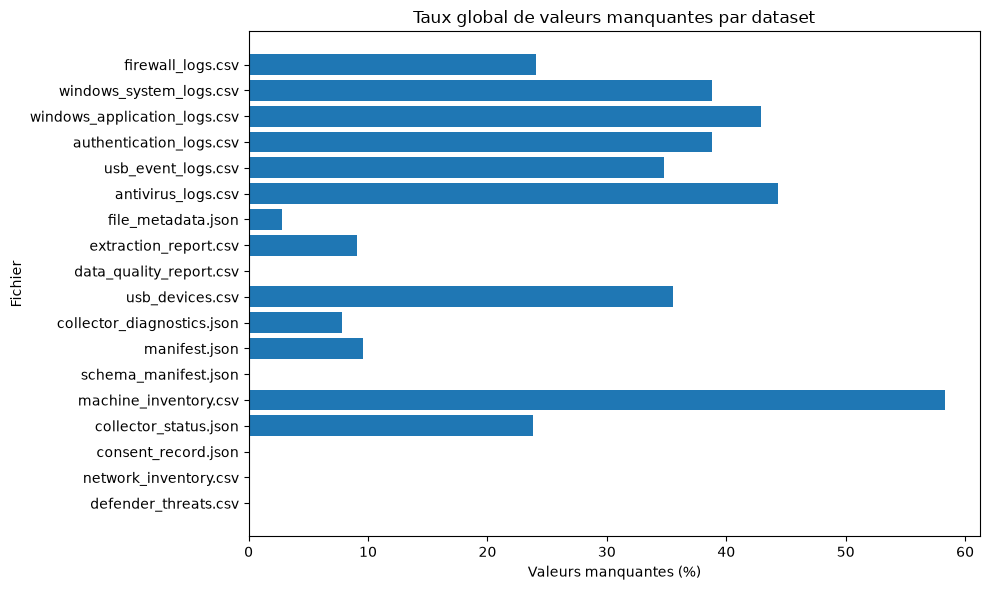

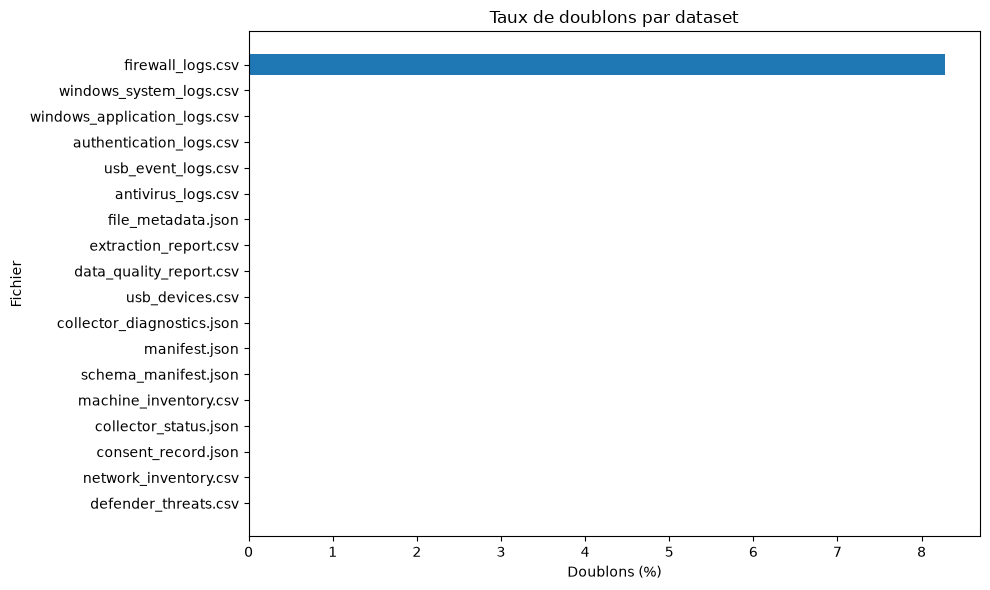

In [13]:
successful_summary = dataset_summary_df[
    dataset_summary_df["status"] == "Success"
].copy()

if not successful_summary.empty:
    plot_df = successful_summary.sort_values("rows", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["file_name"], plot_df["rows"])
    plt.title("Nombre de lignes par dataset")
    plt.xlabel("Nombre de lignes")
    plt.ylabel("Fichier")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.barh(
        plot_df["file_name"],
        plot_df["missing_rate_pct"],
    )
    plt.title("Taux global de valeurs manquantes par dataset")
    plt.xlabel("Valeurs manquantes (%)")
    plt.ylabel("Fichier")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.barh(
        plot_df["file_name"],
        plot_df["duplicate_rate_pct"],
    )
    plt.title("Taux de doublons par dataset")
    plt.xlabel("Doublons (%)")
    plt.ylabel("Fichier")
    plt.tight_layout()
    plt.show()


## 9. Export des rapports

In [14]:
dataset_summary_df.to_csv(
    PROFILE_DIR / "dataset_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

column_profile_df.to_csv(
    PROFILE_DIR / "column_profile.csv",
    index=False,
    encoding="utf-8-sig",
)

quality_issues_df.to_csv(
    PROFILE_DIR / "quality_issues.csv",
    index=False,
    encoding="utf-8-sig",
)

# Rapport Excel multi-feuilles
excel_path = PROFILE_DIR / "pc1_data_profiling.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    inventory_df.to_excel(
        writer,
        sheet_name="File Inventory",
        index=False,
    )
    dataset_summary_df.to_excel(
        writer,
        sheet_name="Dataset Summary",
        index=False,
    )
    column_profile_df.to_excel(
        writer,
        sheet_name="Column Profile",
        index=False,
    )
    quality_issues_df.to_excel(
        writer,
        sheet_name="Quality Issues",
        index=False,
    )
    common_columns_df.to_excel(
        writer,
        sheet_name="Common Columns",
        index=False,
    )
    entities_df.to_excel(
        writer,
        sheet_name="Entities",
        index=False,
    )

# Rapport JSON
json_report = {
    "generated_at": datetime.now().isoformat(),
    "pc_name": PC_NAME,
    "raw_directory": str(RAW_PC_DIR),
    "files_analyzed": int(
        dataset_summary_df["status"].eq("Success").sum()
    ),
    "files_failed": int(
        dataset_summary_df["status"].eq("Failed").sum()
    ),
    "total_rows": int(
        pd.to_numeric(
            dataset_summary_df["rows"],
            errors="coerce",
        ).fillna(0).sum()
    ),
    "quality_issues_count": len(quality_issues_df),
}

with (PROFILE_DIR / "profiling_summary.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        json_report,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Rapports générés dans:", PROFILE_DIR)
print("-", PROFILE_DIR / "file_inventory.csv")
print("-", PROFILE_DIR / "dataset_summary.csv")
print("-", PROFILE_DIR / "column_profile.csv")
print("-", PROFILE_DIR / "quality_issues.csv")
print("-", PROFILE_DIR / "common_columns.csv")
print("-", PROFILE_DIR / "entities_frequency.csv")
print("-", excel_path)
print("-", PROFILE_DIR / "profiling_summary.json")


Rapports générés dans: C:\Users\user1\cybersentinel-analytics\data\profiling\pc1
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\file_inventory.csv
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\dataset_summary.csv
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\column_profile.csv
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\quality_issues.csv
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\common_columns.csv
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\entities_frequency.csv
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\pc1_data_profiling.xlsx
- C:\Users\user1\cybersentinel-analytics\data\profiling\pc1\profiling_summary.json


## 10. Synthèse automatique avant Silver Layer

In [15]:
total_rows = int(
    pd.to_numeric(
        dataset_summary_df["rows"],
        errors="coerce",
    ).fillna(0).sum()
)

total_duplicates = int(
    pd.to_numeric(
        dataset_summary_df["duplicate_rows"],
        errors="coerce",
    ).fillna(0).sum()
)

high_issues = (
    quality_issues_df["severity"]
    .isin(["high", "critical"])
    .sum()
    if not quality_issues_df.empty
    else 0
)

print("=" * 70)
print("CYBERSENTINEL — PC1 DATA PROFILING SUMMARY")
print("=" * 70)
print(f"Datasets analysés      : {len(loaded_datasets)}")
print(f"Total lignes           : {total_rows:,}")
print(f"Total doublons          : {total_duplicates:,}")
print(f"Problèmes détectés      : {len(quality_issues_df):,}")
print(f"Problèmes high/critical : {high_issues:,}")
print()
print("Étapes Silver recommandées:")

recommendations = [
    "Supprimer ou traiter les doublons identifiés.",
    "Convertir toutes les colonnes temporelles en UTC.",
    "Uniformiser les noms des colonnes.",
    "Normaliser hostname, username et adresses IP.",
    "Définir une stratégie pour les valeurs manquantes.",
    "Standardiser les niveaux de sévérité.",
    "Créer un schéma commun pour les événements de sécurité.",
    "Conserver source_file, source_type et ingestion_timestamp.",
]

for index, recommendation in enumerate(recommendations, start=1):
    print(f"{index}. {recommendation}")


CYBERSENTINEL — PC1 DATA PROFILING SUMMARY
Datasets analysés      : 18
Total lignes           : 198,738
Total doublons          : 8,282
Problèmes détectés      : 757
Problèmes high/critical : 355

Étapes Silver recommandées:
1. Supprimer ou traiter les doublons identifiés.
2. Convertir toutes les colonnes temporelles en UTC.
3. Uniformiser les noms des colonnes.
4. Normaliser hostname, username et adresses IP.
5. Définir une stratégie pour les valeurs manquantes.
6. Standardiser les niveaux de sévérité.
7. Créer un schéma commun pour les événements de sécurité.
8. Conserver source_file, source_type et ingestion_timestamp.
